# 01 · Data cleaning and exploratory analysis

**Question.** Can an *elite* Arabica lot (Total Cup Points ≥ 85) be recognised from information available **before** anyone tastes it — origin, altitude, variety, processing method, bean colour, moisture and defect counts?

This notebook loads the raw [Coffee Quality Institute](https://database.coffeeinstitute.org/) export (1,311 graded Arabica lots), applies the cleaning rules implemented in `coffee_quality.data`, defines the target and looks at what separates excellent lots from the rest.

All logic lives in the `coffee_quality` package; the notebook only calls it and comments on the output, so that `scripts/run_pipeline.py`, the tests and the notebooks can never disagree.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from coffee_quality import config as C
from coffee_quality import data, eda, plotting as P

P.set_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

## 1. Raw data

In [2]:
raw = data.load_raw()
print(raw.shape)
raw.head(3)

(1311, 44)


,Unnamed: 0,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,Region,Producer,Number.of.Bags,Bag.Weight,In.Country.Partner,...,Cupper.Points,Total.Cup.Points,Moisture,Category.One.Defects,Quakers,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,METAD PLC,300,60 kg,METAD Agricultural Development plc,...,8.75,90.58,0.12,0,0.0,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,2,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,METAD PLC,300,60 kg,METAD Agricultural Development plc,...,8.58,89.92,0.12,0,0.0,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,3,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,NaN,NaN,5,1,Specialty Coffee Association,...,9.25,89.75,0.00,0,0.0,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0


In [3]:
eda.missingness(raw).head(15)

,dtype,missing_pct,n_unique
Lot.Number,str,79.4,221
Farm.Name,str,27.2,557
Mill,str,23.6,447
Color,str,20.4,3
Producer,str,17.5,675
altitude_mean_meters,float64,17.3,201
altitude_high_meters,float64,17.3,188
altitude_low_meters,float64,17.3,188
Altitude,str,17.0,383
Company,str,15.9,270


The export mixes three kinds of columns: administrative identifiers (owner, mill, certification body…), the ten **sensory scores** given by the cupping panel, and a handful of **pre-harvest / physical attributes** (altitude, variety, processing method, colour, moisture, defect counts).

Only the last group is a legitimate predictor for our question. The sensory scores are the *components* of `Total.Cup.Points`; using them would be circular (see notebook 05 and `docs/LESSONS_LEARNED.md`).

## 2. Cleaning

In [4]:
df, report = data.clean_data(raw, data.load_coordinates())
df = data.add_target(df)
report.to_frame()

,step,rows
0,raw,1311
1,drop Total.Cup.Points == 0,1310
2,drop rows without country and region,1309
3,drop implausible altitudes,1266
4,drop Processing.Method == Other,1240
5,"recode Moisture == 0 as missing (229 rows, no ...",1240


Every step is deterministic and target-agnostic:

* the single row with `Total.Cup.Points == 0` is a placeholder (all sensory scores are zero too);
* 43 lots report an altitude below 200 m or above 3,300 m — up to 190,164 m: unit and typing errors, dropped;
* `Processing.Method == "Other"` (26 lots, none excellent) caused perfect separation in the logistic regression;
* **`Moisture == 0` is not a measurement** (green coffee is 10–12% water). It appears in 18% of the rows, concentrated in a few certifying labs, and — because those labs also grade a disproportionate share of excellent lots — it would act as a hidden proxy. It is recoded as missing and imputed *inside* the modelling pipeline together with an explicit `Moisture_missing` indicator.

Missing altitudes (18%) are **not** filled here: the country/region means used to impute them must be estimated on the training split only, so that step is a scikit-learn transformer (`RegionAltitudeImputer`).

In [5]:
df.isna().sum()[lambda s: s > 0]

Region                   55
Moisture                229
altitude_mean_meters    225
dtype: int64

## 3. Target: what is an *excellent* coffee?

,count,percentage
Excellent,,
Not excellent,1137,91.69
Excellent,103,8.31


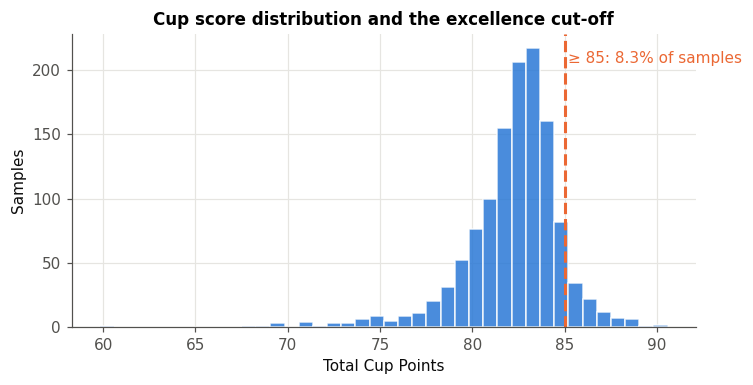

In [6]:
P.plot_score_distribution(df, C.EXCELLENT_THRESHOLD);
eda.class_balance(df)

The cut-off at 85 points follows the specialty-coffee convention (≥ 85 is typically labelled *excellent* / *outstanding*). It leaves **103 positives out of 1,240 (8.3%)** — a strongly imbalanced problem in which accuracy is meaningless (predicting "not excellent" for everything scores 92%) and precision–recall trade-offs are the whole story.

## 4. Which pre-harvest variables move with excellence?

In [7]:
eda.mann_whitney_by_class(df, C.NUMERIC_FEATURES).round(4)

,feature,median_not_excellent,median_excellent,mean_difference,p_value
0,altitude_mean_meters,1310.64,1635.00,278.2479,0.0000
1,Moisture,0.11,0.11,-0.0141,0.0000
2,Category.Two.Defects,2.00,1.00,-1.5304,0.0098
3,Category.One.Defects,0.00,0.00,-0.2350,0.2404


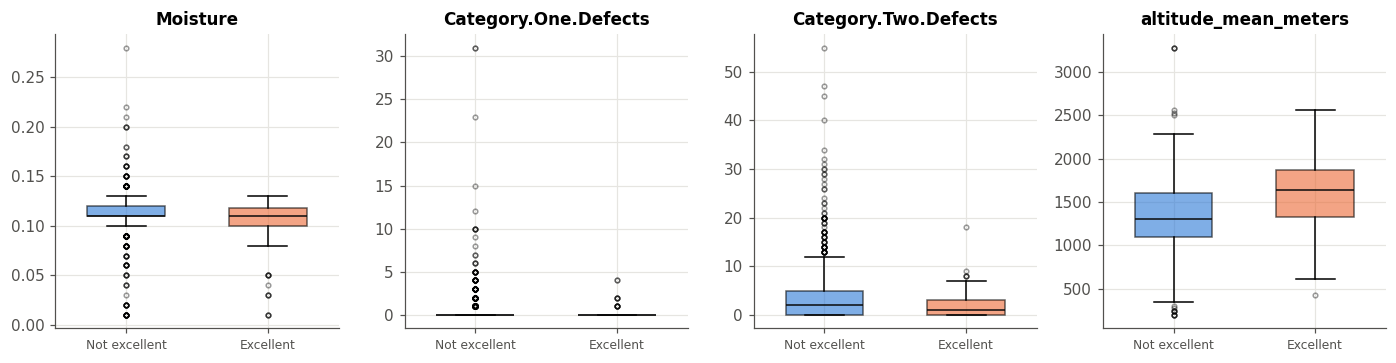

In [8]:
P.plot_numeric_by_class(df, C.NUMERIC_FEATURES);

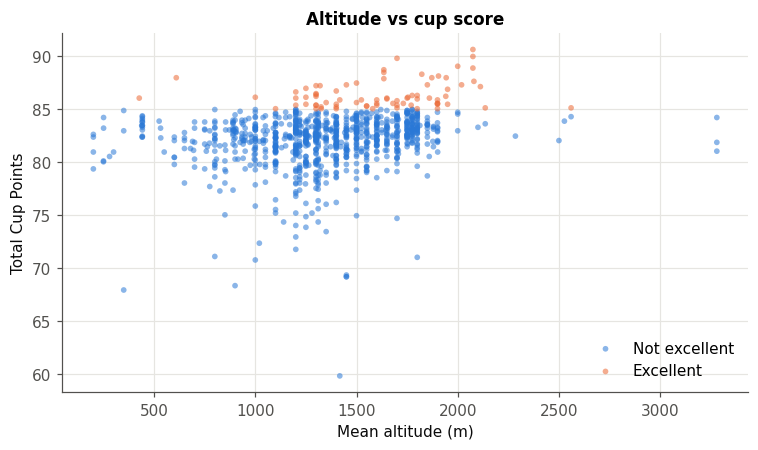

In [9]:
P.plot_altitude_vs_score(df);

Altitude is the clearest signal: excellent lots grow on average ~280 m higher (median 1,635 m vs 1,311 m, Mann–Whitney p ≈ 10⁻¹¹). Lower moisture and fewer secondary (category-two) defects also go with quality, while primary (category-one) defects are too rare to matter statistically. None of the distributions is separable, though: the excellent lots sit *inside* the bulk of the others.

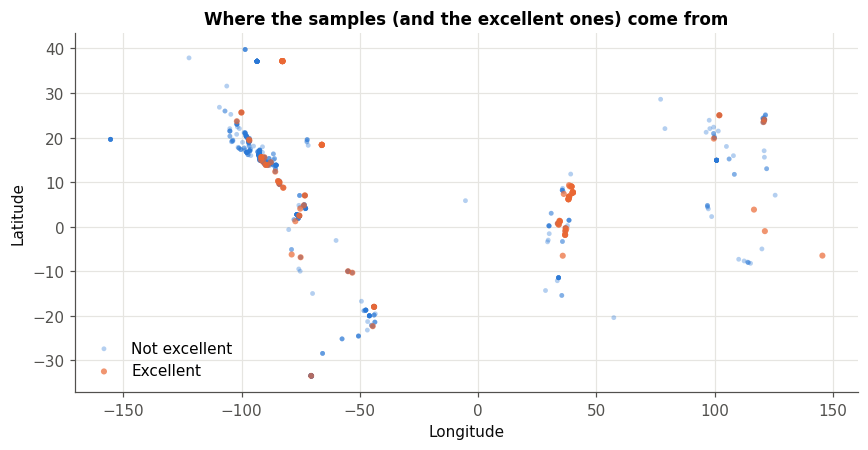

In [10]:
P.plot_geo_scatter(df);

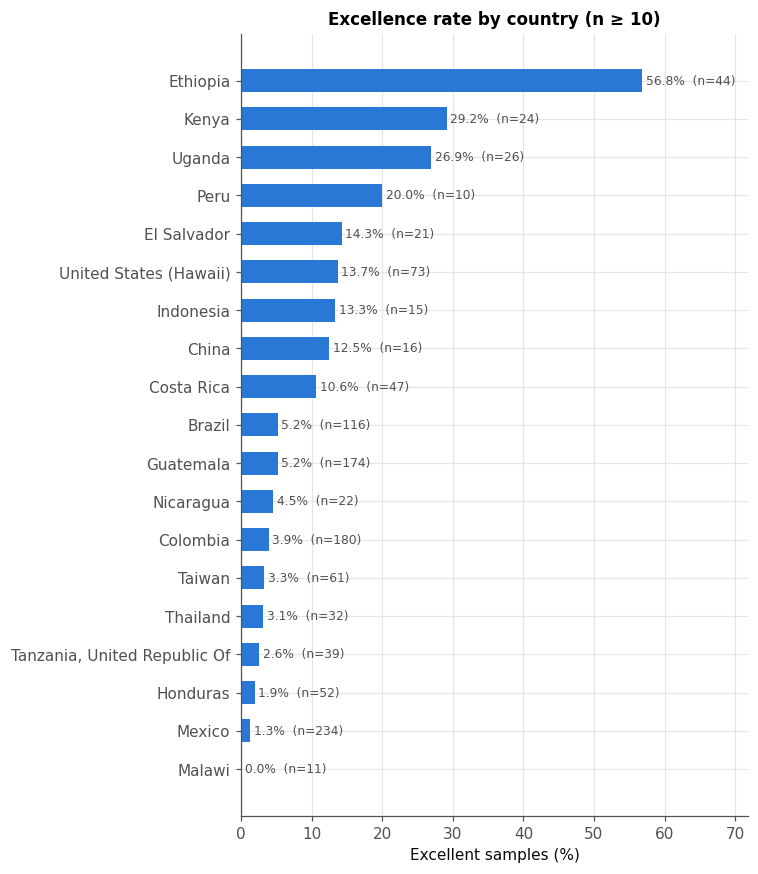

In [11]:
P.plot_rate_by_category(eda.rate_by(df, "Country.of.Origin"), "Excellence rate by country (n ≥ 10)");

In [12]:
for col in ["Processing.Method", "Color", "Variety"]:
    display(eda.rate_by(df, col).round(3))

,n,n_excellent,excellence_rate,mean_score
Processing.Method,,,,
Unknown,147,24,0.163,82.950
Natural,236,28,0.119,82.404
Semi-washed,53,6,0.113,82.668
Honey,13,1,0.077,82.665
Washed,791,44,0.056,81.976


,n,n_excellent,excellence_rate,mean_score
Color,,,,
Unknown,258,39,0.151,82.423
blue-green,189,18,0.095,82.694
green,793,46,0.058,82.025


,n,n_excellent,excellence_rate,mean_score
Variety,,,,
Sumatra Lintong,1,1,1.000,85.170
Ethiopian Yirgacheffe,2,1,0.500,85.960
SL34,8,4,0.500,84.384
Sumatra,3,1,0.333,83.917
SL14,17,5,0.294,83.912
Pacamara,8,2,0.250,82.574
SL28,15,3,0.200,84.006
Unknown,198,32,0.162,82.680
Other,98,14,0.143,82.752


Geography carries a lot of the signal — Ethiopia alone contributes a quarter of the excellent lots at a 57% rate, Kenya and Uganda follow — but country and especially region (300+ levels) would let a model memorise individual farms. The pipelines therefore collapse origin into **five macro-areas** (`MacroAreaMapper`).

Two artefacts are worth remembering when reading model outputs later: the `Unknown` processing method has the highest excellence rate (it is mostly Ethiopian lots with missing metadata), and the same happens for the `Unknown`/`Other` varieties. "Missing" is informative here, which is why missing categories are kept as explicit levels rather than imputed.

## 5. What goes into the models

| Group | Columns | Handling |
|---|---|---|
| numeric | `Moisture`, `Category.One.Defects`, `Category.Two.Defects`, `altitude_mean_meters` | altitude & moisture imputed on the training fold, standardised |
| categorical | `MacroArea` (from country), `Color`, `Processing.Method`, `Variety` | one-hot; varieties beyond the 10 most frequent pooled into *Rare* |
| excluded | sensory scores, `Total.Cup.Points`, `Country`/`Region`, coordinates, identifiers | target leakage / memorisation / no information |

Continue with notebook 02 (unsupervised structure) or jump to 03 (supervised models).